In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('synthetic_student_performance.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [3]:
print("Columns:", df.columns.tolist())
print("\nUnique GradeClass values:", df['GradeClass'].unique())
print("\nCounts per grade:\n", df['GradeClass'].value_counts().sort_index())
print("\nMissing values:\n", df.isnull().sum())

Columns: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Unique GradeClass values: [1 2 0 3]

Counts per grade:
 GradeClass
0    2175
1    1152
2    1023
3     650
Name: count, dtype: int64

Missing values:
 StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


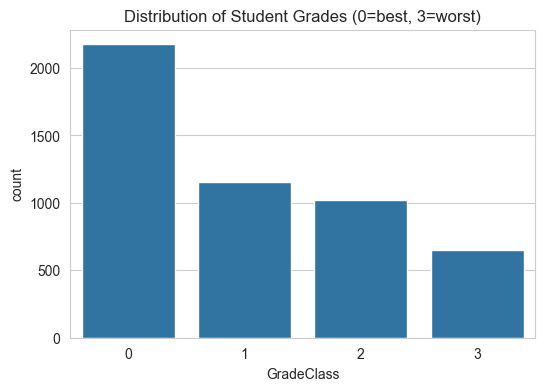

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='GradeClass', data=df)
plt.title('Distribution of Student Grades (0=best, 3=worst)')
plt.show()

In [5]:
feature_cols = ['StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular']
X = df[feature_cols]
y = df['GradeClass']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 5)
Target shape: (5000,)


In [6]:
df[feature_cols].describe()  #Show min max to highlight diff features.

,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,10.031800,15.065200,0.312200,2.296600,0.59480
std,6.019438,8.922223,0.463437,1.223817,0.49098
min,0.000000,0.000000,0.000000,0.000000,0.00000
25%,5.000000,8.000000,0.000000,2.000000,0.00000
50%,10.000000,15.000000,0.000000,2.000000,1.00000
75%,15.000000,23.000000,1.000000,3.000000,1.00000
max,20.000000,30.000000,1.000000,4.000000,1.00000


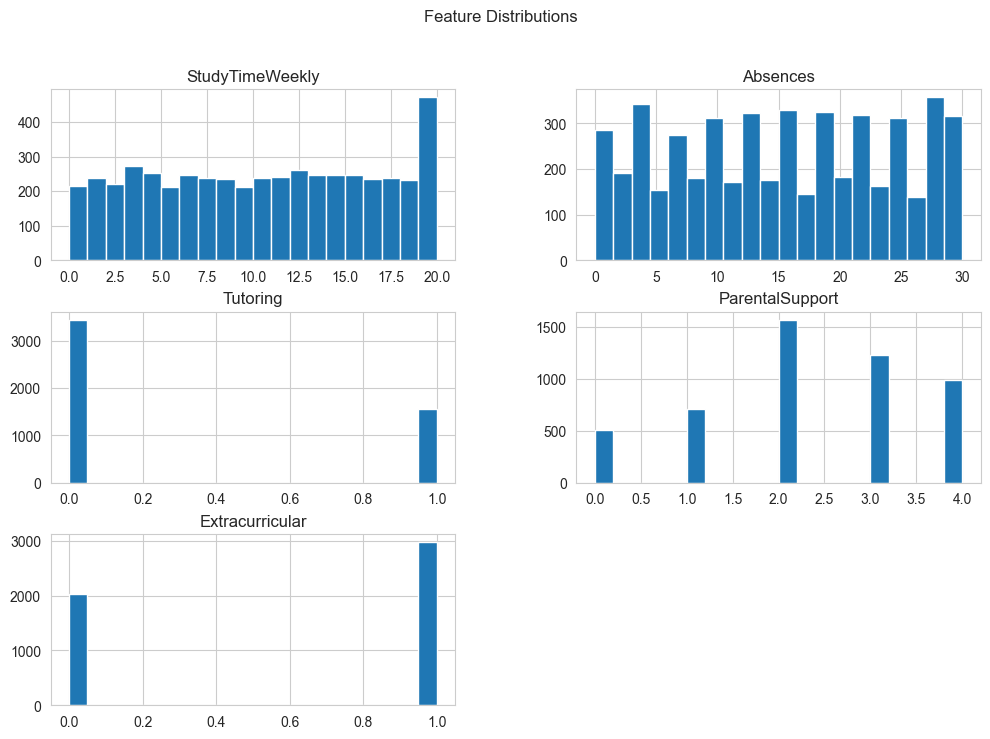

In [7]:
df[feature_cols].hist(figsize=(12,8), bins=20)
plt.suptitle('Feature Distributions')
plt.show()

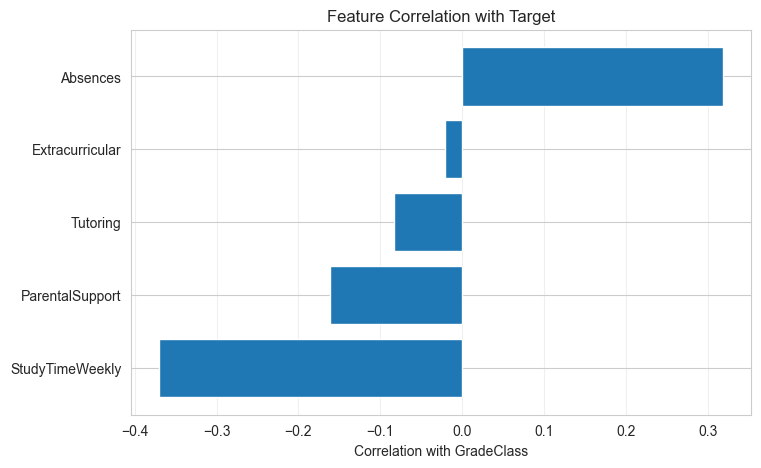

Correlation with GradeClass:
StudyTimeWeekly   -0.369837
ParentalSupport   -0.161839
Tutoring          -0.083080
Extracurricular   -0.021584
Absences           0.317774
dtype: float64


In [8]:
correlations = df[feature_cols].corrwith(df['GradeClass']).sort_values()

plt.figure(figsize=(8,5))
plt.barh(correlations.index, correlations.values)
plt.xlabel('Correlation with GradeClass')
plt.title('Feature Correlation with Target')
plt.grid(axis='x', alpha=0.3)
plt.show()
print("Correlation with GradeClass:")
print(correlations)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 4000
Test samples: 1000


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'saga']}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
model = grid_search.best_estimator_

Best parameters: {'C': 0.1, 'solver': 'lbfgs'}


In [12]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.47

Confusion Matrix:
[[370   2  31  18]
 [167   4  34  31]
 [133   2  33  36]
 [ 38   3  30  68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.88      0.66       421
           1       0.36      0.02      0.03       236
           2       0.26      0.16      0.20       204
           3       0.44      0.49      0.47       139

    accuracy                           0.47      1000
   macro avg       0.40      0.39      0.34      1000
weighted avg       0.42      0.47      0.39      1000



In [13]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

Cross-validation accuracy: 0.48 (+/- 0.01)


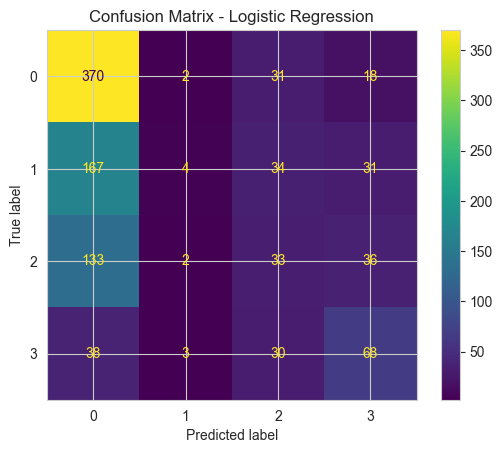

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [15]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.478

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.87      0.66       421
           1       0.24      0.08      0.12       236
           2       0.37      0.08      0.14       204
           3       0.41      0.55      0.47       139

    accuracy                           0.48      1000
   macro avg       0.39      0.39      0.34      1000
weighted avg       0.41      0.48      0.40      1000



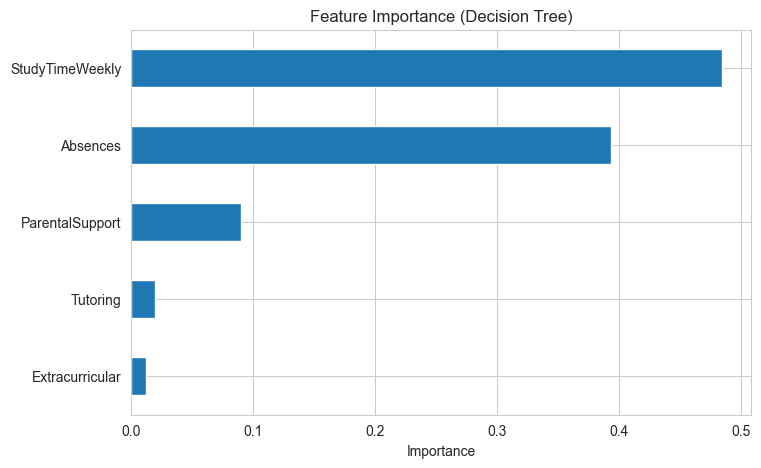

In [16]:
importances = dt_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance')
plt.show()

In [17]:
import joblib
joblib.dump(model, 'grade_classifier.pkl')
print("Model saved as 'grade_classifier.pkl'")

Model saved as 'grade_classifier.pkl'
